In [53]:
import asyncio
import os
import random
import statistics
import time
import json
import numpy as np

from openai import AsyncOpenAI, OpenAI

from models.core_models.registry import MODEL_API_PRICING


# Use the same pinned model as the repository's GPT adapter.
API_KEY = os.environ.get("OPENAI_API_KEY")
if not API_KEY:
    raise RuntimeError("Set OPENAI_API_KEY before running this notebook.")

BASE_URL = os.environ.get("OPENAI_BASE_URL", "https://yibuapi.com/v1")
MODEL = os.environ.get("OPENAI_MODEL", "gpt-4o")
MODEL = "gpt-4o"
MODEL = "gpt-4o-mini-2024-07-18"

NUM_TRIALS = 5
RANDOM_SEED = 20260722
# if MODEL not in MODEL_API_PRICING:
#     raise RuntimeError(f"No adapter pricing is registered for {MODEL!r}.")
MODEL_PRICE = MODEL_API_PRICING[MODEL]

client = OpenAI(api_key=API_KEY, base_url=BASE_URL)
async_client = AsyncOpenAI(api_key=API_KEY, base_url=BASE_URL)


# This body is identical in every request and is intentionally long enough to
# cross the usual 1,024-token prompt-caching threshold. The condition-specific
# label occurs near the beginning, so unique-label requests cannot reuse the
# long cached prefix even though their lengths and remaining text are the same.
LONG_BODY = "\n".join(
    f"Record {i:04d}: alpha beta gamma delta epsilon zeta eta theta; "
    f"the measurement protocol and reporting format remain constant."
    for i in range(100)
)


def calculate_cost(prompt_tokens: int | None, completion_tokens: int | None) -> float | None:
    """Apply the same token-cost formula as API_LLM._accumulate_cost()."""
    if prompt_tokens is None or completion_tokens is None:
        return None
    return (
        prompt_tokens * MODEL_PRICE["input"]
        + completion_tokens * MODEL_PRICE["output"]
    )


def make_prompt(first_token: str, prefix_label: str, trial: int | str) -> str:
    """Build equal-structure prompts whose first differing token is the label."""
    return (
        f"{first_token}mm,mmmmmm prefix variant {prefix_label}.\n"
        f"{LONG_BODY}\n\n"
        # f"Trial {trial}: Summarize the records in one sentence."
    )


def send_request(first_token:str, condition: str, prefix_label: str, trial: int | str) -> dict:
    prompt = make_prompt(first_token, prefix_label, trial)
    start = time.perf_counter()
    response = client.chat.completions.create(
    # raw_response = client.chat.completions.with_raw_response.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=1,
        temperature=1,
        # prompt_cache_key="tenant:acme:knowledge-base-v1",
    )

    # print(dict(raw_response.headers))

    elapsed = time.perf_counter() - start
    # response = raw_response.parse()

    # # OpenAI reports server-side request processing separately from the
    # # client-observed round trip. Compatible proxies may omit this header.
    # processing_ms_header = raw_response.headers.get("openai-processing-ms")
    # try:
    #     processing_ms = (
    #         float(processing_ms_header)
    #         if processing_ms_header is not None
    #         else None
    #     )
    # except ValueError:
    #     processing_ms = None

    usage = getattr(response, "usage", None)
    prompt_tokens = getattr(usage, "prompt_tokens", None) if usage else None
    completion_tokens = getattr(usage, "completion_tokens", None) if usage else None
    details = getattr(usage, "prompt_tokens_details", None) if usage else None
    cache_write = getattr(details, "cached_write_tokens", 0) or 0 if details else 0
    cache_hit = getattr(details, "cached_tokens", 0) or 0 if details else 0
    request_cost = calculate_cost(prompt_tokens, completion_tokens)
    cost_text = f"${request_cost:.6f}" if request_cost is not None else "N/A"
    # processing_text = (
    #     f"{processing_ms / 1000:.3f}s" if processing_ms is not None else "N/A"
    # )

    print(
        f"{condition:7s} trial {str(trial):>6s}: {elapsed:.3f}s | "
        f"prompt: {prompt_tokens} | cache write: {cache_write} | "
        f"cache hit: {cache_hit} | "
        f"output: {completion_tokens} | cost: {cost_text}"
    )
    return {
        "condition": condition,
        "trial": trial,
        "latency": elapsed,
        # "server_processing_ms": processing_ms,
        "prompt_tokens": prompt_tokens,
        "cache_write": cache_write,
        "cache_hit": cache_hit,
        "completion_tokens": completion_tokens,
        "cost": request_cost,
    }




def print_total_cost(results: list[dict]) -> None:
    """Estimate total cost from API-reported usage, including warm-up."""
    complete_rows = [
        row
        for row in results
        if row["cost"] is not None
    ]
    if not complete_rows:
        print("\nCost unavailable: the provider returned no token usage.")
        return

    cached_tokens = sum(
        min(row["cached_tokens"], row["prompt_tokens"]) for row in complete_rows
    )
    prompt_tokens = sum(row["prompt_tokens"] for row in complete_rows)
    uncached_tokens = prompt_tokens - cached_tokens
    output_tokens = sum(row["completion_tokens"] for row in complete_rows)
    total_cost = sum(row["cost"] for row in complete_rows)

    print("\n================ TOTAL EXPERIMENT COST ================")
    print(f"Requests counted: {len(complete_rows)}/{len(results)}")
    print(f"Input tokens: {prompt_tokens} ({cached_tokens} cached, {uncached_tokens} uncached)")
    print(f"Output tokens: {output_tokens}")
    print(f"Adapter-calculated total: ${total_cost:.6f}")
    print(
        "Registry rates per 1M tokens: "
        f"input ${MODEL_PRICE['input'] * 1_000_000:g}, "
        f"output ${MODEL_PRICE['output'] * 1_000_000:g}"
    )
    print("Formula: prompt_tokens * input_rate + completion_tokens * output_rate")
    print("Cached tokens remain part of prompt_tokens, matching API_LLM._accumulate_cost().")
    if len(complete_rows) != len(results):
        print("WARNING: estimate excludes requests without usage data.")
    print("=======================================================")


# # Warm the shared prefix once; this request is deliberately excluded from stats.
# print("--- Warming shared prefix (excluded from results) ---")
# warmup_result = send_request("warmup", "A", "warmup")

# # Interleave both conditions to reduce bias from time-varying server/network load.
# # Shared requests reuse label A. Each unique request uses a different one-token label,
# # causing an early mismatch while retaining the same prompt structure and length.
# jobs = []
# for trial in range(1, NUM_TRIALS + 1):
#     jobs.append(("shared", "A", trial))
#     jobs.append(("unique", chr(ord("A") + trial), trial))
# random.Random(RANDOM_SEED).shuffle(jobs)

# print("\n--- Running randomized controlled trials ---")
# sync_results = [send_request(*job) for job in jobs]
# summarize(sync_results, "SYNCHRONOUS RESULTS")


# # Launch all requests together after label A has been warmed. This tests whether
# # already-populated prompt caching still applies under concurrent async traffic.
# # Unique labels G-K differ near the start and act as equal-length controls.
# async_jobs = []
# for trial in range(1, NUM_TRIALS + 1):
#     async_jobs.append(("shared", "A", f"async-{trial}"))
#     async_jobs.append(("unique", chr(ord("F") + trial), f"async-{trial}"))
# random.Random(RANDOM_SEED + 1).shuffle(async_jobs)

# print("\n--- Running concurrent asynchronous trials ---")
# async_results = await asyncio.gather(
#     *(send_request_async(*job) for job in async_jobs)
# )
# summarize(async_results, "ASYNCHRONOUS RESULTS")

# all_results = [warmup_result, *sync_results, *async_results]
# print_total_cost(all_results)


In [ ]:
# Interleave both conditions to reduce bias from time-varying server/network load.
# Shared requests reuse label A. Each unique request uses a different one-token label,
# causing an early mismatch while retaining the same prompt structure and length.
jobs = []

REPEAT_CACHE = 15
NO_CACHE = 15

for trial in range(1, REPEAT_CACHE + 1):
    jobs.append(("7788", "shared", "A", 0))

for trial in range(1, NO_CACHE + 1):
    jobs.append(("7788", "unique", chr(ord("A") + trial), trial))
    
# random.Random(RANDOM_SEED).shuffle(jobs)

print("\n--- Running randomized controlled trials ---")
sync_results = [send_request(*job) for job in jobs]
# summarize(sync_results, "SYNCHRONOUS RESULTS")



print_total_cost(all_results)

In [ ]:
def measure_zero_content_round_trip() -> dict:
    """Send empty user content and return timing and API usage information."""
    started = time.perf_counter()
    try:
        response = client.chat.completions.create(
            model=MODEL,
            messages=[{"role": "user", "content": ""}],
            max_tokens=1,
            temperature=0,
        )
    except Exception as exc:
        elapsed = time.perf_counter() - started
        return {
            "elapsed_seconds": elapsed,
            "prompt_tokens": None,
            "completion_tokens": None,
            "cost": None,
            "error": str(exc),
        }

    elapsed = time.perf_counter() - started
    usage = getattr(response, "usage", None)
    prompt_tokens = getattr(usage, "prompt_tokens", None)
    completion_tokens = getattr(usage, "completion_tokens", None)
    return {
        "elapsed_seconds": elapsed,
        "prompt_tokens": prompt_tokens,
        "completion_tokens": completion_tokens,
        "cost": calculate_cost(prompt_tokens, completion_tokens),
        "error": None,
    }


In [13]:
NUM_ITERS = 100

zero_content_results = []
for iteration in range(1, NUM_ITERS + 1):
    result = measure_zero_content_round_trip()
    result["iteration"] = iteration
    zero_content_results.append(result)
    if result["error"] is None:
        print(f"Iteration {iteration:>3}: {result['elapsed_seconds']:.6f}s")
    else:
        print(
            f"Iteration {iteration:>3}: request failed after "
            f"{result['elapsed_seconds']:.6f}s — {result['error']}"
        )

reported_costs = [row["cost"] for row in zero_content_results if row["cost"] is not None]
if reported_costs:
    total_experiment_cost = sum(reported_costs)
    print(
        f"\nTotal for-loop experiment cost: ${total_experiment_cost:.8f} "
        f"({len(reported_costs)}/{NUM_ITERS} requests with usage data)"
    )
else:
    total_experiment_cost = None
    print("\nTotal for-loop experiment cost unavailable: no token usage was reported.")

# zero_content_results


Iteration   1: 1.265365s
Iteration   2: 0.963022s
Iteration   3: 0.981143s
Iteration   4: 0.618705s
Iteration   5: 0.963076s
Iteration   6: 1.155211s
Iteration   7: 0.998468s
Iteration   8: 2.258995s
Iteration   9: 0.911173s
Iteration  10: 1.486679s
Iteration  11: 0.859832s
Iteration  12: 1.142725s
Iteration  13: 1.469691s
Iteration  14: 1.247647s
Iteration  15: 1.099147s
Iteration  16: 0.873795s
Iteration  17: 1.069130s
Iteration  18: 0.693451s
Iteration  19: 0.683206s
Iteration  20: 0.860184s
Iteration  21: 0.959418s
Iteration  22: 0.945125s
Iteration  23: 0.970179s
Iteration  24: 1.238836s
Iteration  25: 0.813500s
Iteration  26: 0.982029s
Iteration  27: 0.800557s
Iteration  28: 0.876909s
Iteration  29: 1.597170s
Iteration  30: 0.904877s
Iteration  31: 1.315933s
Iteration  32: 1.165089s
Iteration  33: 1.347169s
Iteration  34: 0.854044s
Iteration  35: 1.336199s
Iteration  36: 0.798185s
Iteration  37: 0.885073s
Iteration  38: 1.090380s
Iteration  39: 1.005145s
Iteration  40: 0.780703s


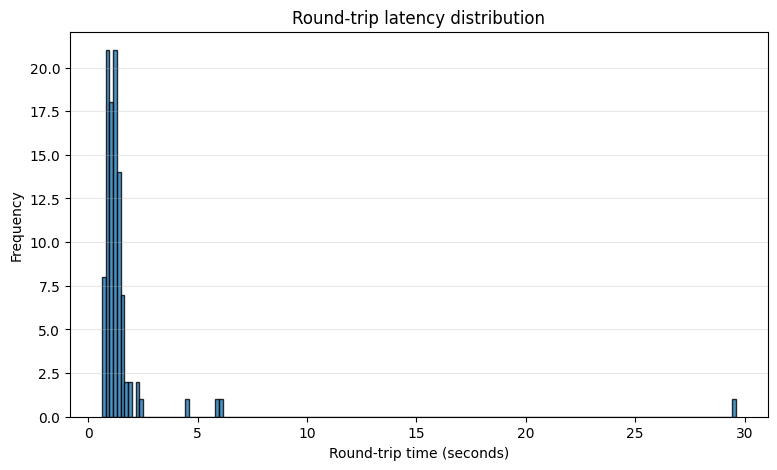

In [14]:
import matplotlib.pyplot as plt

successful_results = [row for row in zero_content_results if row["error"] is None]
iterations = [row["iteration"] for row in successful_results]
latencies = [row["elapsed_seconds"] for row in successful_results]

# fig, ax = plt.subplots(figsize=(9, 5))
# ax.scatter(iterations, latencies, s=55, color="tab:blue")
# ax.set(
#     title="Empty-content request round-trip latency",
#     xlabel="Iteration",
#     ylabel="Round-trip time (seconds)",
# )
# ax.set_xticks(range(1, NUM_ITERS + 1))
# ax.grid(True, alpha=0.3)
# plt.show()


plt.figure(figsize=(9, 5))
plt.hist(latencies, bins="auto", color="tab:blue", edgecolor="black", alpha=0.8)
plt.title("Round-trip latency distribution")
plt.xlabel("Round-trip time (seconds)")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.show()



In [18]:
latencies = np.array(latencies)

In [22]:
np.mean(latencies[latencies<4])-2*np.std(latencies[latencies<4])

np.float64(0.486769809702818)

In [20]:
np.std(latencies[latencies<4])

np.float64(0.3425682261089487)

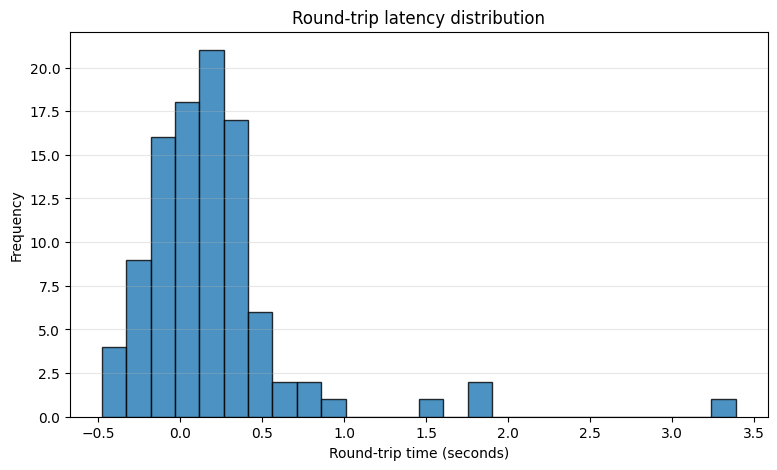

In [21]:
plt.figure(figsize=(9, 5))
plt.hist(np.log(latencies), bins="auto", color="tab:blue", edgecolor="black", alpha=0.8)
plt.title("Round-trip latency distribution")
plt.xlabel("Round-trip time (seconds)")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.show()



In [51]:
# Raw HTTP diagnostic: sends one paid, non-streaming completion request.
# The bearer token is read from the environment and is never printed.
import os

import requests


diagnostic_api_key = os.environ.get("OPENAI_API_KEY")
if not diagnostic_api_key:
    raise RuntimeError("Set OPENAI_API_KEY before running this cell.")

diagnostic_base_url = os.environ.get(
    "OPENAI_BASE_URL", "https://yibuapi.com/v1"
).rstrip("/")
diagnostic_url = f"{diagnostic_base_url}/chat/completions"
diagnostic_model = "gpt-4o-mini-2024-07-18"

diagnostic_headers = {
    "Authorization": f"Bearer {diagnostic_api_key}",
    "Content-Type": "application/json",
}
diagnostic_payload = {
    "model": diagnostic_model,
    "messages": [{"role": "user", "content": "Reply with exactly: OK"}],
    "max_tokens": 1,
    "temperature": 0,
}

started = time.perf_counter()
diagnostic_response = requests.post(
    diagnostic_url,
    headers=diagnostic_headers,
    json=diagnostic_payload,
    timeout=120,
)
elapsed = time.perf_counter() - started

# print(f"URL: {diagnostic_url}")
# print(f"HTTP status: {diagnostic_response.status_code}")
# print("Response headers:")
# for header_name, header_value in sorted(diagnostic_response.headers.items()):
#     print(f"  {header_name}: {header_value}")

# if not diagnostic_response.ok:
#     print("Response body:")
#     print(diagnostic_response.text)

elapsed

1.558063286007382

In [56]:
diagnostic_response.__attrs__

['_content',
 'status_code',
 'headers',
 'url',
 'history',
 'encoding',
 'reason',
 'cookies',
 'elapsed',
 'request']

In [63]:
diagnostic_response.elapsed

datetime.timedelta(seconds=1, microseconds=557190)

In [69]:
content = json.loads(diagnostic_response._content.decode("utf-8"))
content

{'choices': [{'finish_reason': 'length',
   'index': 0,
   'logprobs': None,
   'message': {'annotations': [],
    'content': 'OK',
    'refusal': None,
    'role': 'assistant'}}],
 'created': 1784819055,
 'id': 'chatcmpl-E4pG3njlskOMdHSN8Ur9Qmu1zfcBv',
 'model': 'gpt-4o-mini-2024-07-18',
 'object': 'chat.completion',
 'service_tier': 'default',
 'system_fingerprint': 'fp_27599ce29d',
 'usage': {'completion_tokens': 1,
  'completion_tokens_details': {'accepted_prediction_tokens': 0,
   'audio_tokens': 0,
   'reasoning_tokens': 0,
   'rejected_prediction_tokens': 0},
  'latency_checkpoint': {'engine_tbt_ms': 1,
   'engine_ttft_ms': 49,
   'engine_ttlt_ms': 50,
   'pre_inference_ms': 125,
   'service_tbt_ms': 10,
   'service_ttft_ms': 644,
   'service_ttlt_ms': 644,
   'total_duration_ms': 528,
   'user_visible_ttft_ms': 518},
  'prompt_tokens': 12,
  'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0},
  'total_tokens': 13}}

In [71]:
content.keys()
content['usage'].keys()

dict_keys(['completion_tokens', 'completion_tokens_details', 'latency_checkpoint', 'prompt_tokens', 'prompt_tokens_details', 'total_tokens'])

In [80]:
diagnostic_api_key = os.environ.get("OPENAI_API_KEY")
if not diagnostic_api_key:
    raise RuntimeError("Set OPENAI_API_KEY before running this cell.")

diagnostic_base_url = os.environ.get(
    "OPENAI_BASE_URL", "https://yibuapi.com/v1"
).rstrip("/")
diagnostic_url = f"{diagnostic_base_url}/chat/completions"
diagnostic_model = "gpt-4o-mini-2024-07-18"

diagnostic_headers = {
    "Authorization": f"Bearer {diagnostic_api_key}",
    "Content-Type": "application/json",
}

def send_post_response(first_token:str, condition: str, prefix_label: str, trial: int | str) -> dict:
    prompt = make_prompt(first_token, prefix_label, trial)

    diagnostic_payload = {
        "model": diagnostic_model,
        "messages": [{"role": "user", "content": prompt}],
        "max_tokens": 1,
        "temperature": 1,
    }

    diagnostic_response = requests.post(
        diagnostic_url,
        headers=diagnostic_headers,
        json=diagnostic_payload,
        timeout=120,
    )

    content = json.loads(diagnostic_response._content.decode("utf-8"))
    usage = content['usage']
    latency_checkpoint = usage['latency_checkpoint']
    
    prompt_tokens = usage['prompt_tokens']
    completion_tokens = usage['total_tokens'] - prompt_tokens
    cache_hit = usage['prompt_tokens_details']['cached_tokens']
    request_cost = calculate_cost(prompt_tokens, completion_tokens)
    cost_text = f"${request_cost:.6f}" if request_cost is not None else "N/A"
    elapsed = diagnostic_response.elapsed.total_seconds()

    engine_ttlt_ms = latency_checkpoint['engine_ttlt_ms']

    print(
        f"{condition:7s} trial {str(trial):>6s}: engine {engine_ttlt_ms}ms | "
        f"elapsed {elapsed} | "
        f"prompt: {prompt_tokens} | "
        f"cache hit: {cache_hit} | "
        f"output: {completion_tokens} | cost: {cost_text}"
    )
    return {
        "condition": condition,
        "trial": trial,
        "engine_ttft_ms": engine_ttlt_ms,
        "total_elapsed": elapsed,
        "prompt_tokens": prompt_tokens,
        "cached_tokens": cache_hit,
        "completion_tokens": completion_tokens,
        "cost": request_cost,
    }


In [81]:
# Interleave both conditions to reduce bias from time-varying server/network load.
# Shared requests reuse label A. Each unique request uses a different one-token label,
# causing an early mismatch while retaining the same prompt structure and length.
jobs = []

REPEAT_CACHE = 15
NO_CACHE = 15

for trial in range(1, REPEAT_CACHE + 1):
    jobs.append(("h723", "shared", "A", 0))

for trial in range(1, NO_CACHE + 1):
    jobs.append(("h723", "unique", chr(ord("A") + trial), trial))
    
# random.Random(RANDOM_SEED).shuffle(jobs)

print("\n--- Running randomized controlled trials ---")
post_sync_results = [send_post_response(*job) for job in jobs]
# summarize(sync_results, "SYNCHRONOUS RESULTS")



print_total_cost(post_sync_results)


--- Running randomized controlled trials ---
shared  trial      0: engine 71ms | elapsed 1.073371 | prompt: 2417 | cache hit: 2304 | output: 1 | cost: $0.000726
shared  trial      0: engine 38ms | elapsed 0.994164 | prompt: 2417 | cache hit: 2304 | output: 1 | cost: $0.000726
shared  trial      0: engine 57ms | elapsed 1.109211 | prompt: 2417 | cache hit: 2304 | output: 1 | cost: $0.000726
shared  trial      0: engine 36ms | elapsed 1.482603 | prompt: 2417 | cache hit: 2304 | output: 1 | cost: $0.000726
shared  trial      0: engine 53ms | elapsed 1.279529 | prompt: 2417 | cache hit: 2304 | output: 1 | cost: $0.000726
shared  trial      0: engine 44ms | elapsed 1.286955 | prompt: 2417 | cache hit: 2304 | output: 1 | cost: $0.000726
shared  trial      0: engine 52ms | elapsed 1.154341 | prompt: 2417 | cache hit: 2304 | output: 1 | cost: $0.000726
shared  trial      0: engine 49ms | elapsed 1.572091 | prompt: 2417 | cache hit: 2304 | output: 1 | cost: $0.000726
shared  trial      0: engi